In [ ]:
import os
import numpy as np
import cv2
from scipy.signal import butter, filtfilt
import matplotlib.pyplot as plt

folder = "../data/OutputVideos/Cardiac_cycle_1s"

# tri correct : Image_T01, Image_T02, ...
files = sorted(f for f in os.listdir(folder) if f.endswith(".png"))

fps = 34

ROI = (0, 0, 1024, 1024)

G_signal = []
x, y, w, h = ROI  # ta région d’intérêt

for f in files:
    img = cv2.imread(os.path.join(folder, f))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    roi = img[y:y+h, x:x+w]

    # moyenne canal vert
    G_mean = np.mean(roi[:, :, 1])
    G_signal.append(G_mean)

G_signal = np.array(G_signal)

# 🔹 Normalisation demandée : (Amplitude/moyenne) - 1
mean_val = np.mean(G_signal)

print(mean_val)
print(G_signal)
G_norm = (G_signal / mean_val) - 1
print(G_norm)

200.00608236649458
[200.25431919 199.99873352 199.59017754 199.37786198 199.31722355
 199.3475399  199.43591499 199.58460999 199.6944952  199.82020187
 200.04137611 200.28213215 200.28754616 200.20519161 200.05615997
 199.98387814 199.98387814 200.10065937 200.13928413 200.14993763
 200.16757107 200.16162491 200.17110157 200.18684006 200.17115593
 200.18522072 200.18284321 200.18522072 200.18581295 200.19214344
 200.19623661 200.19623661 200.17790508 200.19576645]
[ 1.24114638e-03 -3.67431125e-05 -2.07946091e-03 -3.14100643e-03
 -3.44418934e-03 -3.29261219e-03 -2.85075017e-03 -2.10729782e-03
 -1.55788845e-03 -9.29374200e-04  1.76463370e-04  1.38020694e-03
  1.40727616e-03  9.95515953e-04  2.50380419e-04 -1.11017778e-04
 -1.11017778e-04  4.72870639e-04  6.65988583e-04  7.19254442e-04
  8.07418951e-04  7.77689059e-04  8.25070926e-04  9.03760969e-04
  8.25342715e-04  8.95664521e-04  8.83777332e-04  8.95664521e-04
  8.98625589e-04  9.30277077e-04  9.50742306e-04  9.50742306e-04
  8.5908745

In [18]:
def bandpass(signal, fps, low=0.7, high=3.0, order=4):
    nyquist = 0.5 * fps
    low = low / nyquist
    high = high / nyquist
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, signal)

G_filt = bandpass(G_norm, 34)

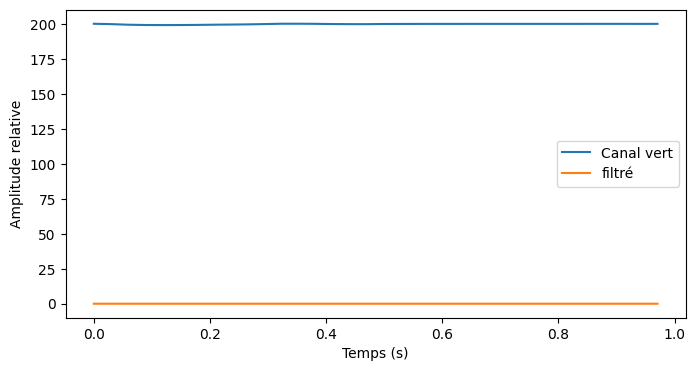

In [19]:
# plot
t = np.arange(len(G_signal))/fps
plt.figure(figsize=(8,4))
plt.plot(t, G_signal, label='Canal vert')
plt.plot(t, G_filt, label='filtré')
plt.xlabel("Temps (s)")
plt.ylabel("Amplitude relative")
plt.legend()
plt.show()

# Comparer les différents signaux rPPG

In [ ]:
#Paramètres
base_folder = "C:/Users/marin/ssynth-release/data/results_images/Variation_spp"
folders = [
    "Cardiac_cycle1", "Cardiac_cycle2", "Cardiac_cycle4", "Cardiac_cycle8",
    "Cardiac_cycle16", "Cardiac_cycle32","Cardiac_cycle64","Cardiac_cycle128","Cardiac_cycle1024"]
fps = 35.0


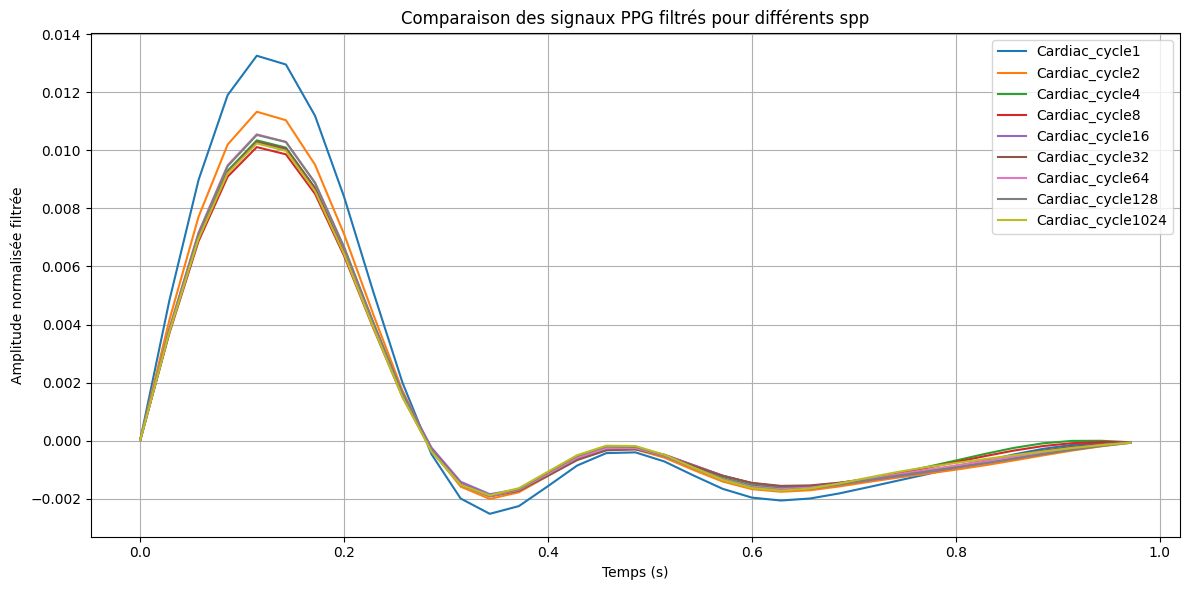

In [ ]:
# Extraction et affichage
plt.figure(figsize=(12, 6))

for folder in folders:

    path = os.path.join(base_folder, folder)
    files = sorted(f for f in os.listdir(path) if f.endswith(".exr"))

    G_signal = []

    # Charger toutes les images du dossier
    for f in files:
        img = load_exr(os.path.join(path, f))
        G_signal.append(np.mean(img[:,:,1]))  # moyenne canal vert

    G_signal = np.array(G_signal)

    # Normalisation
    G_signal = (np.mean(G_signal) - G_signal) / np.mean(G_signal)

    # Filtrage
    G_filt = bandpass(G_signal, fps)

    # Temps
    t = np.arange(len(G_signal)) / fps

    # Tracer chaque signal sur le même graphique
    plt.plot(t, G_filt, label=folder)

plt.xlabel("Temps (s)")
plt.ylabel("Amplitude normalisée filtrée")
plt.title("Comparaison des signaux PPG filtrés pour différents spp")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()